In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime
import pytz
import re

plt.style.use('default')

In [2]:
#Loading dataset
df = pd.read_csv("C:/Users/yashr/Desktop/eve4/google_play_store_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
print(df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [4]:
#cleaning ratings
df['Rating'] = pd.to_numeric(
    df['Rating'],
    errors='coerce'
)

In [5]:
#Cleaning Reviews
df['Reviews'] = pd.to_numeric(
    df['Reviews'],
    errors='coerce'
)

In [6]:
#Cleaning installs
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(
    df['Installs'],
    errors='coerce'
)

In [7]:
#Cleaning size
df = df[df['Size'] != 'Varies with device']

df = df[
    df['Size'].astype(str).str.contains('M')
]

df['Size_MB'] = (
    df['Size']
    .str.replace('M', '', regex=False)
    .astype(float)
)

In [8]:
#Converting data
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [9]:
#Applying filters
filtered = df[
    (df['Rating'] >= 4.2) &
    (df['Reviews'] > 1000) &
    (df['Size_MB'].between(20, 80)) &
    (df['Category'].str.startswith(('T', 'P')))
]

filtered = filtered[
    ~filtered['App'].str.contains(
        r'\d',
        regex=True,
        na=False
    )
]

print("Filtered Shape:", filtered.shape)

Filtered Shape: (139, 14)


In [10]:
#Verifying categories
print(
    filtered['Category']
    .value_counts()
)

Category
PHOTOGRAPHY         54
TRAVEL_AND_LOCAL    32
PRODUCTIVITY        21
TOOLS               17
PERSONALIZATION     11
PARENTING            4
Name: count, dtype: int64


In [11]:
#Creating monthly column
filtered['Month'] = (
    filtered['Last Updated']
    .dt.to_period('M')
)

In [12]:
#Aggregating Installs by Month and Category
monthly = (
    filtered
    .groupby(
        ['Month', 'Category']
    )['Installs']
    .sum()
    .reset_index()
)

monthly.head()

,Month,Category,Installs
0,2014-11,PHOTOGRAPHY,1000000.0
1,2016-10,PRODUCTIVITY,1000000.0
2,2016-12,PERSONALIZATION,2000000.0
3,2017-03,PHOTOGRAPHY,50000000.0
4,2017-06,PHOTOGRAPHY,10000000.0


In [13]:
#Pivot Table
pivot = monthly.pivot(
    index='Month',
    columns='Category',
    values='Installs'
).fillna(0)

pivot.index = pivot.index.to_timestamp()

pivot.head()

Category,PARENTING,PERSONALIZATION,PHOTOGRAPHY,PRODUCTIVITY,TOOLS,TRAVEL_AND_LOCAL
Month,,,,,,
2014-11-01,0.0,0.0,1000000.0,0.0,0.0,0.0
2016-10-01,0.0,0.0,0.0,1000000.0,0.0,0.0
2016-12-01,0.0,2000000.0,0.0,0.0,0.0,0.0
2017-03-01,0.0,0.0,50000000.0,0.0,0.0,0.0
2017-06-01,0.0,0.0,10000000.0,0.0,0.0,0.0


In [14]:
#Translating Legend Labels
translations = {
    'Travel & Local': 'Voyages et Local',
    'Productivity': 'Productividad',
    'Photography': '写真'
}

pivot.rename(
    columns=translations,
    inplace=True
)

In [15]:
#Calculating Month-over-Month Growth
growth = pivot.pct_change()

In [16]:
#Months with >25% Growth
highlight_months = growth[
    (growth > 0.25).any(axis=1)
].index

print(highlight_months)

DatetimeIndex(['2016-10-01', '2016-12-01', '2017-03-01', '2017-07-01',
               '2017-08-01', '2017-09-01', '2017-10-01', '2017-12-01',
               '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01'],
              dtype='datetime64[ns]', name='Month', freq=None)


In [20]:
#Checking IST time
ist = pytz.timezone('Asia/Kolkata')

current_time = datetime.now(ist)

print("Current IST Time:", current_time)

show_chart = True

print("Show Chart:", show_chart)

Current IST Time: 2026-06-23 11:41:01.695351+05:30
Show Chart: True


In [21]:
#generating colors
num_categories = len(pivot.columns)

colors = plt.cm.tab20(
    np.linspace(
        0,
        1,
        num_categories
    )
)

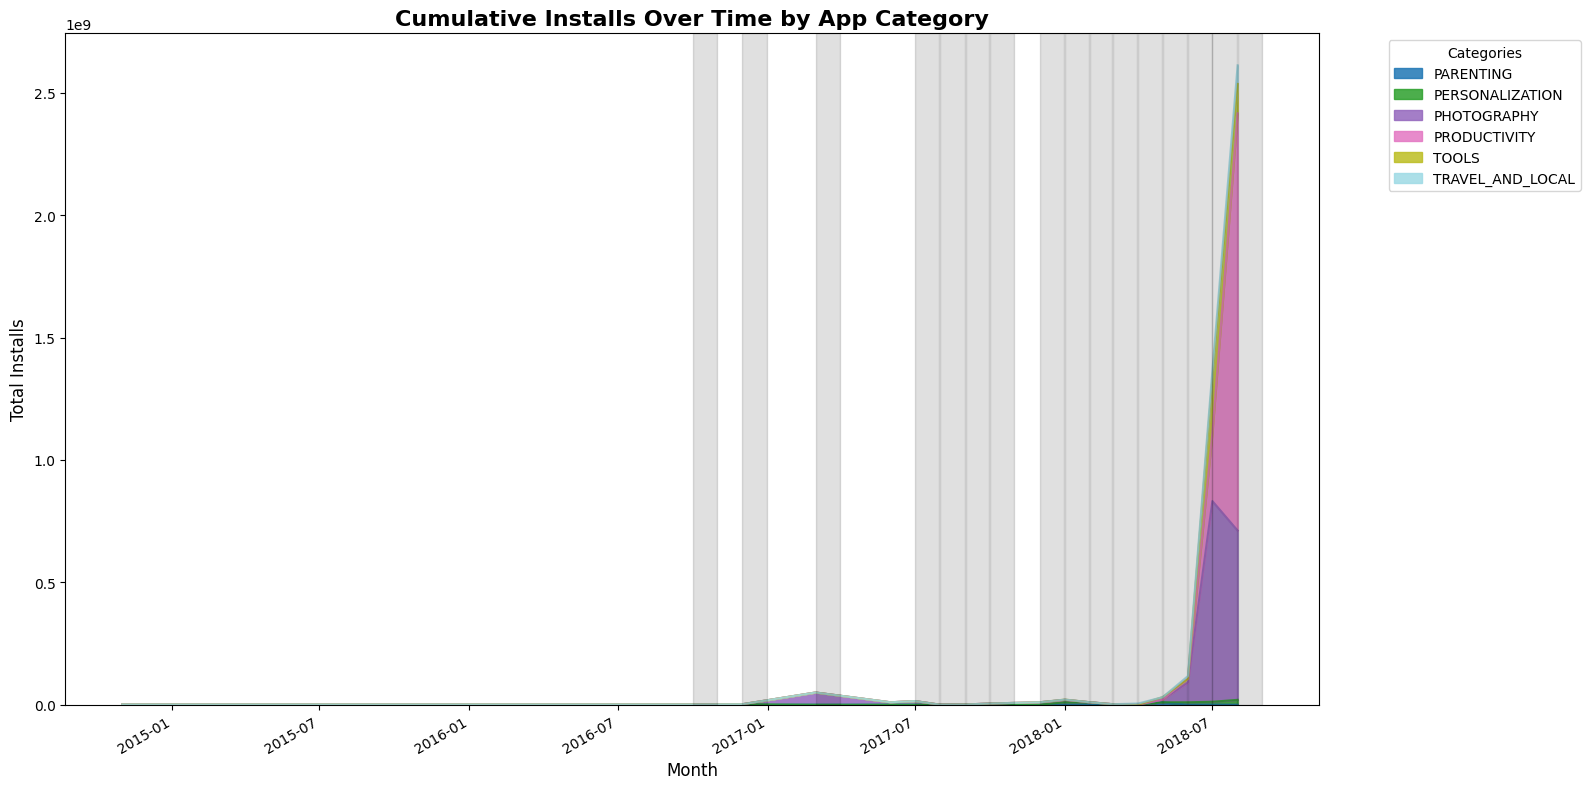

In [22]:
#Stacked Area Chart
if show_chart:

    fig, ax = plt.subplots(
        figsize=(16, 8)
    )

    pivot.plot.area(
        ax=ax,
        color=colors,
        alpha=0.85
    )

    for month in highlight_months:

        ax.axvspan(
            month,
            month + pd.offsets.MonthEnd(1),
            color='black',
            alpha=0.12,
            zorder=10
        )

    ax.set_title(
        'Cumulative Installs Over Time by App Category',
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Month',
        fontsize=12
    )

    ax.set_ylabel(
        'Total Installs',
        fontsize=12
    )

    ax.legend(
        title='Categories',
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "Visualization available only between "
        "4 PM IST and 6 PM IST."
    )